# CHIME FRB Catalog: log N–log S and DM Distribution

- **log N–log S**: cumulative source-count distribution using the `fluence` column.
- **DM distribution**: histogram of `dm_fitb`.

Rows with missing/invalid values in the relevant column are dropped before each plot,
and the number of dropped rows is reported.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/thsu/FRB_population/chimefrbcat2.csv"
df = pd.read_csv(csv_path)

print(f"Total rows in catalog: {len(df)}")
print(df.columns.tolist())


Total rows in catalog: 5045
['tns_name', 'previous_name', 'repeater_name', 'event_id', 'sub_num', 'ra', 'ra_err', 'dec', 'dec_err', 'ra_dec_notes', 'gl', 'gb', 'exp_up', 'exp_up_err', 'exp_low', 'exp_low_err', 'exp_notes', 'bonsai_snr', 'bonsai_dm', 'low_ft_68', 'up_ft_68', 'low_ft_95', 'up_ft_95', 'snr_fitb', 'dm_fitb', 'dm_fitb_err', 'dm_exc_ne2001', 'dm_exc_ymw16', 'bc_width', 'scat_time', 'scat_time_err', 'flux', 'flux_err', 'fluence', 'fluence_err', 'fluence_notes', 'fluence_win_extended', 'mjd_400', 'mjd_400_err', 'mjd_inf', 'mjd_inf_err', 'width_fitb', 'width_fitb_err', 'sp_idx', 'sp_idx_err', 'sp_run', 'sp_run_err', 'high_freq', 'low_freq', 'peak_freq', 'chi_sq', 'dof', 'flag_frac', 'notes_fitb', 'intrachan_flag', 'excluded_flag', 'sidelobe_flag', 'citizen_science_flag', 'catalog1_flag', 'catalog1_param_flag']


## log N–log S (cumulative fluence distribution)

Total FRBs: 5045
Missing fluence: 518
Non-positive fluence (excluded from log plot): 0
Used for log N-log S: 4527


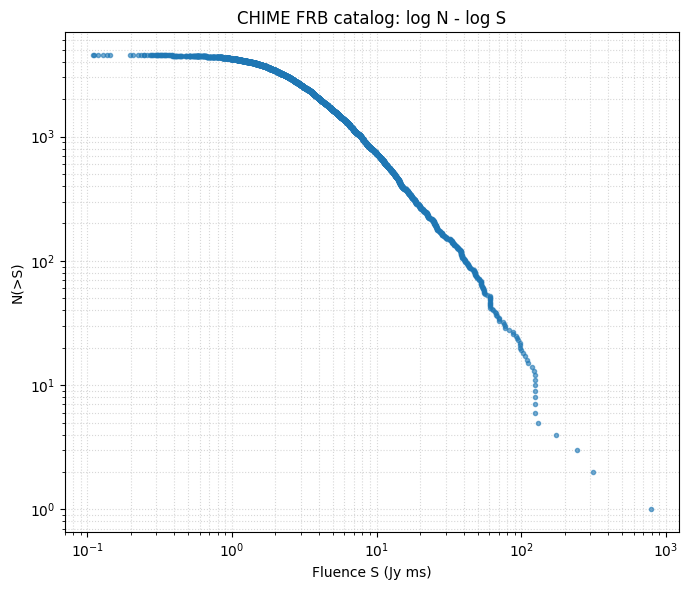

In [37]:
# Extract fluence, drop missing/non-positive values (log requires S > 0)
fluence = pd.to_numeric(df["fluence"], errors="coerce")

n_total = len(fluence)
n_missing = fluence.isna().sum()
n_nonpositive = (fluence <= 0).sum()  # includes NaNs comparison-safe (NaN <= 0 is False, so fine separately)

valid_mask = fluence.notna() & (fluence > 0)
fluence_valid = fluence[valid_mask].to_numpy()

print(f"Total FRBs: {n_total}")
print(f"Missing fluence: {n_missing}")
print(f"Non-positive fluence (excluded from log plot): {(fluence <= 0).sum()}")
print(f"Used for log N-log S: {len(fluence_valid)}")

# Sort descending: S_1 >= S_2 >= ... >= S_n
S_sorted = np.sort(fluence_valid)[::-1]
N_cum = np.arange(1, len(S_sorted) + 1)  # N(>S) for each threshold S = S_sorted[i]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(S_sorted, N_cum, marker="o", linestyle="none", markersize=3, alpha=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Fluence S (Jy ms)")
ax.set_ylabel("N(>S)")
ax.set_title("CHIME FRB catalog: log N - log S")
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()


### Slope estimate (MLE power-law index)

Assuming $N(>S) \propto S^{-\alpha}$ above a completeness threshold `S_min`,
the maximum-likelihood estimator (Crawford, Jauncey & Murdoch 1970) is:

$$\hat{\alpha} = (n-1)\left[\sum_{i=1}^{n-1}\ln\left(\frac{S_i}{S_{min}}\right)\right]^{-1}$$

**You should set `S_min` to the fluence above which the CHIME/FRB survey is reasonably
complete** (e.g. based on the sensitivity/completeness studies in the catalog paper) —
below that, incompleteness will artificially flatten the naive slope. The placeholder
below just uses the median as an illustrative default; replace it with a physically
motivated completeness threshold.


S_min = 3.500 Jy ms
N sources above S_min: 2309
MLE slope (alpha, N(>S) ~ S^-alpha): 1.166 +/- 0.024
Not enough sources above S_min to fit a slope.


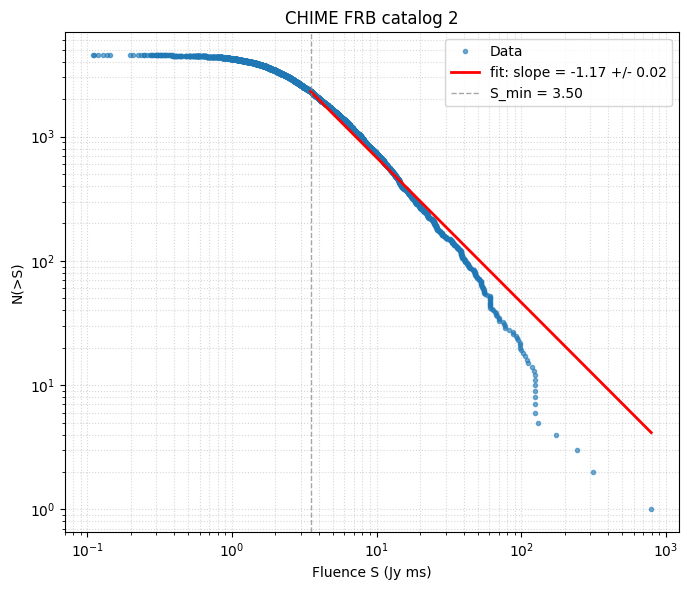

In [38]:
# --- Set your completeness threshold here ---
S_min = 3.5  # Jy ms (from 2.2. Sensitivity Threshold in CHIME/FRB Catalog Paper)

above_thresh = S_sorted[S_sorted >= S_min]
n = len(above_thresh)


alpha_hat = (n ) / np.sum(np.log(above_thresh[:] / S_min))
alpha_err = alpha_hat / np.sqrt(n)
print(f"S_min = {S_min:.3f} Jy ms")
print(f"N sources above S_min: {n}")
print(f"MLE slope (alpha, N(>S) ~ S^-alpha): {alpha_hat:.3f} +/- {alpha_err:.3f}")

print("Not enough sources above S_min to fit a slope.")

# Overlay the fitted power law on the log N - log S plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(S_sorted, N_cum, marker="o", linestyle="none", markersize=3, alpha=0.6, label="Data")

if n > 1:
    S_line = np.linspace(S_min, above_thresh.max(), 100)
    N_at_Smin = np.sum(S_sorted >= S_min)
    N_line = N_at_Smin * (S_line / S_min) ** (-alpha_hat)
    ax.plot(S_line, N_line, color="red", lw=2,
            label=f"fit: slope = -{alpha_hat:.2f} +/- {alpha_err:.2f}")

ax.axvline(S_min, color="gray", ls="--", lw=1, alpha=0.7, label=f"S_min = {S_min:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Fluence S (Jy ms)")
ax.set_ylabel("N(>S)")
ax.set_title("CHIME FRB catalog 2")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


## DM distribution (`dm_fitb`)

Total FRBs: 5045
Missing dm_fitb: 84
Used for DM histogram: 4961


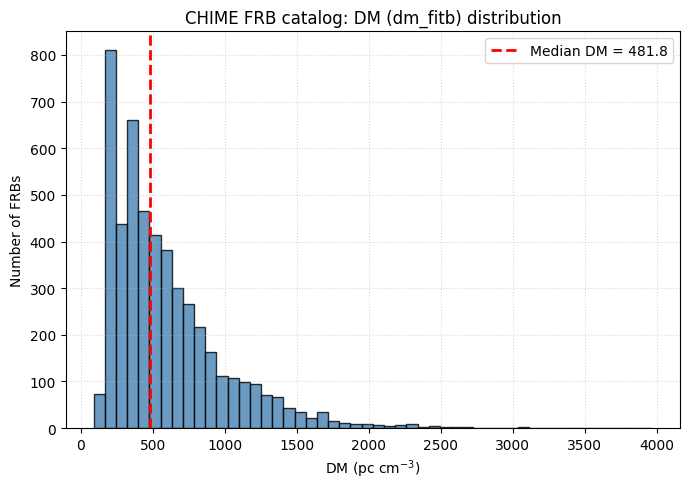

In [39]:
dm = pd.to_numeric(df["dm_fitb"], errors="coerce")

n_dm_missing = dm.isna().sum()
dm_valid = dm.dropna().to_numpy()

print(f"Total FRBs: {len(dm)}")
print(f"Missing dm_fitb: {n_dm_missing}")
print(f"Used for DM histogram: {len(dm_valid)}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(dm_valid, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(np.median(dm_valid), color="red", ls="--", lw=2, label=f"Median DM = {np.median(dm_valid):.1f}")
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("Number of FRBs")
ax.set_title("CHIME FRB catalog: DM (dm_fitb) distribution")
ax.legend()
ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()


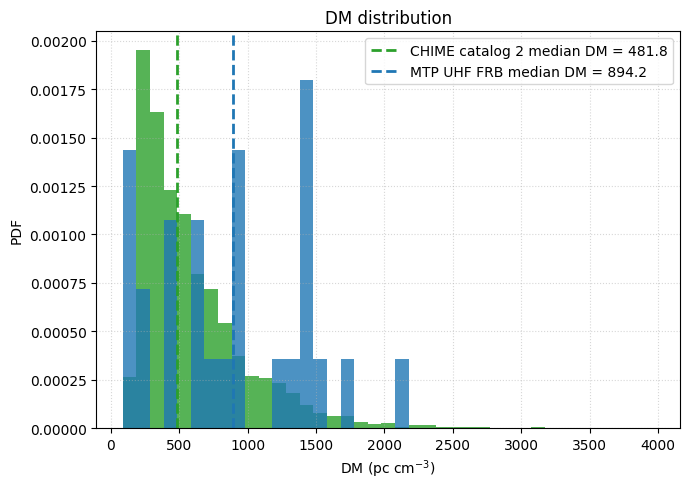

In [40]:

df_mtp = pd.read_csv("/home/thsu/FRB_population/MTP_UHF_DM.csv")
DM_mtp = pd.to_numeric(df_mtp["DM"], errors="coerce")
# Find global DM range
dm_min = min(DM_mtp.min(), dm_valid.min())
dm_max = max(DM_mtp.max(), dm_valid.max())
common_bins = np.linspace(dm_min, dm_max, 40)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(dm_valid, bins=common_bins, density = True, color="tab:green", alpha=0.8)
ax.axvline(np.median(dm_valid), color="tab:green", ls="--", lw=2, label=f"CHIME catalog 2 median DM = {np.median(dm_valid):.1f}")
ax.hist(DM_mtp, bins=common_bins, density = True, color="tab:blue", alpha=0.8)
ax.axvline(np.median(DM_mtp), color="tab:blue", ls="--", lw=2, label=f"MTP UHF FRB median DM = {np.median(DM_mtp):.1f}")
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("PDF")
ax.set_title("DM distribution")
ax.legend()
ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()


21 sources in CB subsample
[CB] S/N_min = 8.000
[CB] N sources above threshold: 21
[CB] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): 1.167 +/- 0.255

10 sources in IB subsample
[IB] S/N_min = 8.000
[IB] N sources above threshold: 10
[IB] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): 0.859 +/- 0.272



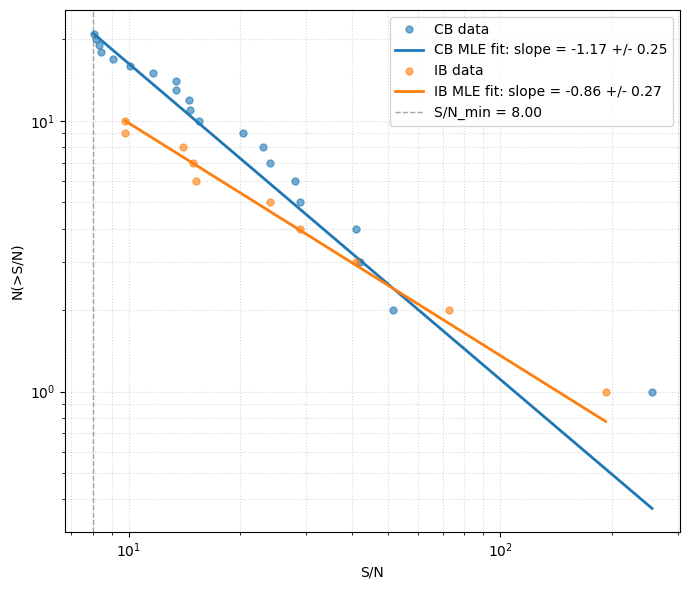

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/thsu/FRB_population/MTP_UHF_DM.csv")

beam = df["Beam"].astype(str).str.strip().str.upper()
snr = df["S/N"].astype(float)

is_cb = beam.isin(["CB", "BOTH"])
is_ib = beam.isin(["IB", "BOTH"])

subsamples = {
    "CB": np.sort(snr[is_cb].dropna().values),
    "IB": np.sort(snr[is_ib].dropna().values),
}

SNR_min = 8 # completeness threshold in S/N -- set to your survey's value

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"CB": "tab:blue", "IB": "tab:orange"}
results = {}

for label, S_sorted in subsamples.items():
    N_cum = np.arange(len(S_sorted), 0, -1)  # N(>S) for each sorted value
    print (len(S_sorted), "sources in", label, "subsample")
    ax.plot(S_sorted, N_cum, marker="o", linestyle="none", markersize=5,
            alpha=0.6, color=colors[label], label=f"{label} data")

    above_thresh = S_sorted[S_sorted >= SNR_min]
    n = len(above_thresh)


    alpha_hat = (n) / np.sum(np.log(above_thresh[:] / SNR_min))
    alpha_err = alpha_hat / np.sqrt(n)
    print(f"[{label}] S/N_min = {SNR_min:.3f}")
    print(f"[{label}] N sources above threshold: {n}")
    print(f"[{label}] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): {alpha_hat:.3f} +/- {alpha_err:.3f}\n")

    S_line = np.linspace(S_sorted.min(), above_thresh.max(), 100)
    N_at_start = len(S_sorted)  # cumulative count at the smallest S/N value
    N_line = N_at_start * (S_line / S_sorted.min()) ** (-alpha_hat)
    ax.plot(S_line, N_line, color=colors[label], lw=2,
            label=f"{label} MLE fit: slope = -{alpha_hat:.2f} +/- {alpha_err:.2f}")

    results[label] = (alpha_hat, alpha_err, n)


ax.axvline(SNR_min, color="gray", ls="--", lw=1, alpha=0.7, label=f"S/N_min = {SNR_min:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("S/N")
ax.set_ylabel("N(>S/N)")
# ax.set_title("log N - log S/N by Beam, with MLE slope fit")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

25 sources in ASKAP Fly's eye sample
[ASKAP Fly's eye] S/N_min = 8.000
[ASKAP Fly's eye] N sources above threshold: 25
[ASKAP Fly's eye] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): 1.626 +/- 0.325

29 sources in Parkes sample
[Parkes] S/N_min = 8.000
[Parkes] N sources above threshold: 29
[Parkes] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): 1.073 +/- 0.199

13 sources in FAST sample
[FAST] S/N_min = 8.000
[FAST] N sources above threshold: 13
[FAST] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): 0.795 +/- 0.220



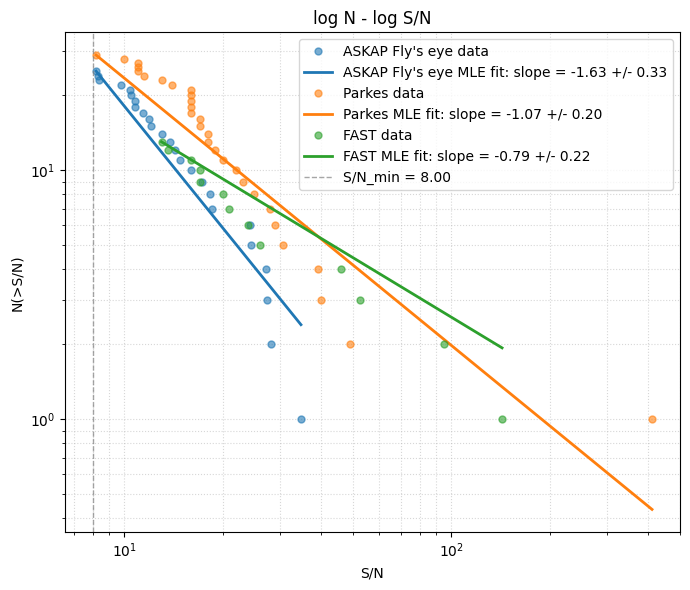

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "ASKAP Fly's eye": "/home/thsu/FRB_population/DM_distribution_real_data/askap_flyeye.csv",
    "Parkes": "/home/thsu/FRB_population/DM_distribution_real_data/parkes.csv",
    "FAST": "/home/thsu/FRB_population/DM_distribution_real_data/fast.csv",
}

SNR_min = 8  # completeness threshold in S/N -- set per-survey if needed

subsamples = {}
for label, path in files.items():
    df = pd.read_csv(path)
    snr = df["S/N"].astype(float)
    subsamples[label] = np.sort(snr.dropna().values)

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"ASKAP Fly's eye": "tab:blue", "Parkes": "tab:orange", "FAST": "tab:green"}
results = {}

for label, S_sorted in subsamples.items():
    N_cum = np.arange(len(S_sorted), 0, -1)  # N(>S) for each sorted value
    print(len(S_sorted), "sources in", label, "sample")
    ax.plot(S_sorted, N_cum, marker="o", linestyle="none", markersize=5,
            alpha=0.6, color=colors[label], label=f"{label} data")

    above_thresh = S_sorted[S_sorted >= SNR_min]
    n = len(above_thresh)

    alpha_hat = (n) / np.sum(np.log(above_thresh[:] / SNR_min))
    alpha_err = alpha_hat / np.sqrt(n)
    print(f"[{label}] S/N_min = {SNR_min:.3f}")
    print(f"[{label}] N sources above threshold: {n}")
    print(f"[{label}] MLE slope (alpha, N(>S/N) ~ S/N^-alpha): {alpha_hat:.3f} +/- {alpha_err:.3f}\n")

    S_line = np.linspace(S_sorted.min(), above_thresh.max(), 100)
    N_at_start = len(S_sorted)  # cumulative count at the smallest S/N value
    N_line = N_at_start * (S_line / S_sorted.min()) ** (-alpha_hat)
    ax.plot(S_line, N_line, color=colors[label], lw=2,
            label=f"{label} MLE fit: slope = -{alpha_hat:.2f} +/- {alpha_err:.2f}")

    results[label] = (alpha_hat, alpha_err, n)

ax.axvline(SNR_min, color="gray", ls="--", lw=1, alpha=0.7, label=f"S/N_min = {SNR_min:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("S/N")
ax.set_ylabel("N(>S/N)")
ax.set_title("log N - log S/N")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

[ASKAP Fly's eye] threshold = 8 S/N | N above = 25 | slope = 1.626 +/- 0.325
[Parkes] threshold = 8 S/N | N above = 29 | slope = 1.073 +/- 0.199
[FAST] threshold = 8 S/N | N above = 13 | slope = 0.795 +/- 0.220
[MeerKAT CB] threshold = 8 S/N | N above = 21 | slope = 1.167 +/- 0.255
[MeerKAT IB] threshold = 8 S/N | N above = 10 | slope = 0.859 +/- 0.272


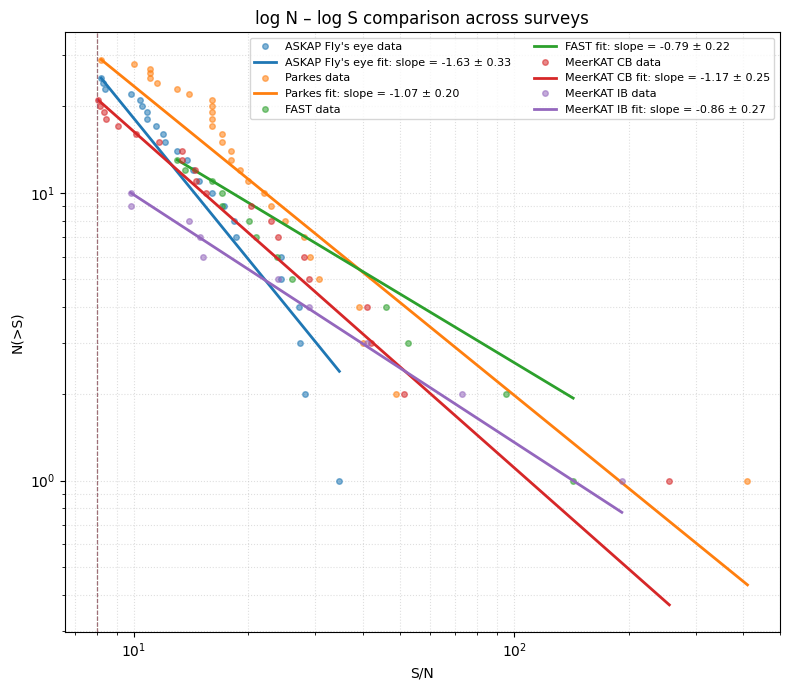

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Load all survey samples
# ---------------------------------------------------------------

# S/N-based surveys
snr_files = {
    "ASKAP Fly's eye": "/home/thsu/FRB_population/DM_distribution_real_data/askap_flyeye.csv",
    "Parkes":           "/home/thsu/FRB_population/DM_distribution_real_data/parkes.csv",
    "FAST":             "/home/thsu/FRB_population/DM_distribution_real_data/fast.csv",
}

# Per-survey completeness threshold in S/N (tune individually if they differ)
SNR_MIN = {
    "ASKAP Fly's eye": 8.0,
    "Parkes": 8.0,
    "FAST": 8.0,
    "MeerKAT CB": 8.0,
    "MeerKAT IB": 8.0,
}

samples = {}  # name -> dict(values=sorted array, unit=str, threshold=float)

for label, path in snr_files.items():
    df = pd.read_csv(path)
    snr = df["S/N"].astype(float).dropna().values
    samples[label] = {"values": np.sort(snr), "unit": "S/N", "threshold": SNR_MIN[label]}

# MeerKAT UHF, split by beam (CB / IB)
mk = pd.read_csv("/home/thsu/FRB_population/MTP_UHF_DM.csv")
beam = mk["Beam"].astype(str).str.strip().str.upper()
snr_mk = mk["S/N"].astype(float)

is_cb = beam.isin(["CB", "BOTH"])
is_ib = beam.isin(["IB", "BOTH"])

samples["MeerKAT CB"] = {"values": np.sort(snr_mk[is_cb].dropna().values), "unit": "S/N", "threshold": SNR_MIN["MeerKAT CB"]}
samples["MeerKAT IB"] = {"values": np.sort(snr_mk[is_ib].dropna().values), "unit": "S/N", "threshold": SNR_MIN["MeerKAT IB"]}

# ---------------------------------------------------------------
# 2. MLE power-law slope for each survey, anchored at its own threshold
# ---------------------------------------------------------------

colors = {
    "ASKAP Fly's eye": "tab:blue",
    "Parkes":          "tab:orange",
    "FAST":            "tab:green",
    "MeerKAT CB":      "tab:red",
    "MeerKAT IB":      "tab:purple",
}

results = {}
fig, ax = plt.subplots(figsize=(8, 7))

for label, d in samples.items():
    S_sorted = d["values"]
    S_min = d["threshold"]
    N_cum = np.arange(len(S_sorted), 0, -1)  # N(>S) at every sorted value

    ax.plot(S_sorted, N_cum, marker="o", linestyle="none", markersize=4,
            alpha=0.55, color=colors[label], label=f"{label} data")

    above = S_sorted[S_sorted >= S_min]
    n = len(above)
    if n < 2:
        print(f"[{label}] fewer than 2 sources above threshold — skipping fit")
        continue

    alpha_hat = n / np.sum(np.log(above / S_min))
    alpha_err = alpha_hat / np.sqrt(n)
    results[label] = (alpha_hat, alpha_err, n)
    print(f"[{label}] threshold = {S_min:g} {d['unit']} | N above = {n} | "
          f"slope = {alpha_hat:.3f} +/- {alpha_err:.3f}")

    S_line = np.linspace(S_sorted.min(), above.max(), 100)  # line spans from smallest S/N point
    N_line = N_cum[0] * (S_line / S_sorted.min()) ** (-alpha_hat)  # anchored at the smallest-S/N data point itself
    ax.plot(S_line, N_line, color=colors[label], lw=2,
            label=f"{label} fit: slope = -{alpha_hat:.2f} ± {alpha_err:.2f}")

    ax.axvline(S_min, color=colors[label], ls="--", lw=0.8, alpha=0.4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("S/N")
ax.set_ylabel("N(>S)")
ax.set_title("log N – log S comparison across surveys")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("/home/thsu/FRB_population/logN_logS_all_surveys.png", dpi=150)
plt.show()